In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# synthetic student performance dataset
np.random.seed(42)
study_hours = np.random.randint(5, 50, 100)
practice_tests = np.random.randint(0, 10, 100)

# Student passes if they study enough AND take enough practice tests (with some randomness added)
passed = ((study_hours + (practice_tests * 3)) > 35).astype(int)

df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Practice_Tests': practice_tests,
    'Pass_Exam': passed
})

display(df.head())

,Study_Hours,Practice_Tests,Pass_Exam
0,43,7,1
1,33,2,1
2,19,2,0
3,47,0,1
4,12,4,0


In [3]:
# Spliting data into training and testing sets
X = df[['Study_Hours', 'Practice_Tests']]
y = df['Pass_Exam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 80 samples
Testing data size: 20 samples


In [4]:
# Train the Decision Tree Classifier using Entropy (Information Gain)
model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


In [5]:
# Evaluate the model performance on unseen test data
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

Model Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        10
        Pass       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



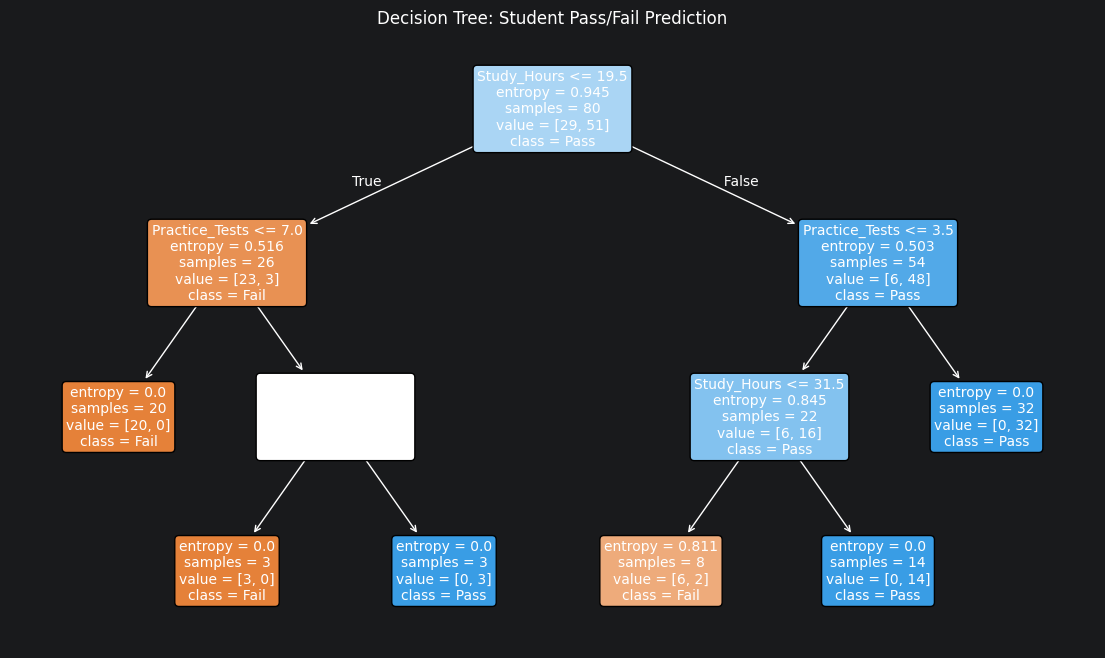

In [6]:
# Visualize the actual Decision Tree splits
plt.figure(figsize=(14, 8))

plot_tree(model,
          feature_names=['Study_Hours', 'Practice_Tests'],
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree: Student Pass/Fail Prediction')
plt.show()